# DARWIN: исправленный пайплайн (без leakage)

Что поправлено относительно `AD_upd_corrected.ipynb`:

1. Номер задачи берётся целиком (`air_time12` → 12), а не последняя цифра.
2. Корреляции и список `to_drop` считаются **только на train**.
3. Мультиколлинеарность: из каждой пары с `|corr| > 0.85` удаляется одна фича.
4. Порядок ячеек: сначала агрегация test, потом scaler.
5. Выделены честные метрики кластеризации: Silhouette + ARI/AMI.
6. Accuracy/ROC надо было считать так: **только после** mapping `cluster → majority class` на train.


## 1. Загрузка и train/test split


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

OUTPUT_DIR = Path("outputs_fixed")
for sub in ["data", "figures", "logs", "models"]:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

darwin = fetch_ucirepo(id=732)
X_raw = darwin.data.features.drop(columns=["ID"])
y = darwin.data.targets["class"].map({"P": 1, "H": 0})

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train_raw)} (P={int(y_train.sum())}, H={int((y_train == 0).sum())})")
print(f"Test:  {len(X_test_raw)} (P={int(y_test.sum())}, H={int((y_test == 0).sum())})")


Train: 139 (P=71, H=68)
Test:  35 (P=18, H=17)


## 2. Агрегация признаков (G / C / M)

**Фикс:** номер задачи = весь числовой хвост имени колонки, не `c[-1]`.


In [3]:
TASK_CATEGORIES = {
    1: "M", 2: "G", 3: "G", 4: "G", 5: "G",
    6: "C", 7: "C", 8: "C", 9: "C", 10: "C",
    11: "C", 12: "C", 13: "C", 14: "M", 15: "C",
    16: "C", 17: "C", 18: "M", 19: "C", 20: "M",
    21: "G", 22: "C", 23: "M", 24: "G", 25: "C",
}

CATEGORY_TASKS = {
    "G": [k for k, v in TASK_CATEGORIES.items() if v == "G"],
    "C": [k for k, v in TASK_CATEGORIES.items() if v == "C"],
    "M": [k for k, v in TASK_CATEGORIES.items() if v == "M"],
}


def extract_prefix(col_name: str) -> str:
    return re.sub(r"_?\d+$", "", col_name)


def extract_task_id(col_name: str) -> int:
    # ПРАВИЛЬНО: весь хвост цифр, не c[-1]
    m = re.search(r"(\d+)$", col_name)
    if not m:
        raise ValueError(f"No task id in column: {col_name}")
    return int(m.group(1))


def build_feature_groups(columns):
    groups = {}
    for col in columns:
        groups.setdefault(extract_prefix(col), []).append(col)
    return groups


def aggregate_by_category(X: pd.DataFrame, feature_groups: dict) -> pd.DataFrame:
    out = pd.DataFrame(index=X.index)
    for group, cols in feature_groups.items():
        if group == "ID":
            continue
        for category, task_list in CATEGORY_TASKS.items():
            cat_cols = [c for c in cols if extract_task_id(c) in task_list]
            if cat_cols:
                out[f"{group}_{category}_mean"] = X[cat_cols].mean(axis=1)
    return out


feature_groups = build_feature_groups(X_train_raw.columns)
X_train_agg = aggregate_by_category(X_train_raw, feature_groups)
X_test_agg = aggregate_by_category(X_test_raw, feature_groups)

assert list(X_train_agg.columns) == list(X_test_agg.columns)
print(f"Aggregated features: {X_train_agg.shape[1]}")
print("Example:", X_train_agg.columns[:6].tolist())


Aggregated features: 54
Example: ['air_time_G_mean', 'air_time_C_mean', 'air_time_M_mean', 'disp_index_G_mean', 'disp_index_C_mean', 'disp_index_M_mean']


## 3. Мультиколлинеарность только на train

Жадно: пока есть пара с `|corr| > 0.85`, удаляем ту фичу из пары, у которой выше средняя `|corr|` с остальными.


In [4]:
CORR_THRESHOLD = 0.85


def drop_high_corr_features(X: pd.DataFrame, threshold: float = CORR_THRESHOLD):
    remaining = list(X.columns)
    dropped = []

    while True:
        corr = X[remaining].corr().abs()
        pairs = (
            corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .sort_values(ascending=False)
        )
        bad = pairs[pairs > threshold]
        if bad.empty:
            break

        f1, f2 = bad.index[0]
        mean_corr = corr.loc[remaining, remaining].mean()
        drop_f = f1 if mean_corr[f1] >= mean_corr[f2] else f2
        remaining.remove(drop_f)
        dropped.append((drop_f, float(bad.iloc[0]), f1 if drop_f == f2 else f2))

    return remaining, dropped


remaining_features, dropped_info = drop_high_corr_features(X_train_agg)
print(f"Dropped {len(dropped_info)} features due to high correlation")
print(f"Remaining: {len(remaining_features)}")

corr_check = X_train_agg[remaining_features].corr().abs()
mask = np.triu(np.ones(corr_check.shape), k=1).astype(bool)
leftover = corr_check.where(mask).stack()
leftover = leftover[leftover > CORR_THRESHOLD]
print(f"Leftover pairs > {CORR_THRESHOLD} on TRAIN: {len(leftover)}")

X_train_clean = X_train_agg[remaining_features].copy()
X_test_clean = X_test_agg[remaining_features].copy()

with open(OUTPUT_DIR / "logs" / "features_kept.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(remaining_features))
with open(OUTPUT_DIR / "logs" / "features_dropped.txt", "w", encoding="utf-8") as f:
    for feat, corr_v, partner in dropped_info:
        f.write(f"{feat}\tcorr={corr_v:.3f}\twith={partner}\n")

print("Kept first 8:", remaining_features[:8])


Dropped 16 features due to high correlation
Remaining: 38
Leftover pairs > 0.85 on TRAIN: 0
Kept first 8: ['air_time_G_mean', 'air_time_C_mean', 'air_time_M_mean', 'disp_index_G_mean', 'disp_index_C_mean', 'disp_index_M_mean', 'gmrt_in_air_G_mean', 'gmrt_in_air_C_mean']


## 4. StandardScaler: fit только на train


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Train scaled:", X_train_scaled.shape)
print("Test scaled: ", X_test_scaled.shape)


Train scaled: (139, 38)
Test scaled:  (35, 38)


## 5. K-Means: подбор k на train (+ CV silhouette)

Тест не участвует в выборе k.


In [6]:
k_range = range(2, 8)
train_sils, cv_sils = [], []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    sil_train = silhouette_score(X_train_scaled, labels)
    train_sils.append(sil_train)

    fold_sils = []
    for tr_idx, va_idx in skf.split(X_train_scaled, y_train):
        km_cv = KMeans(n_clusters=k, random_state=42, n_init=10)
        km_cv.fit(X_train_scaled[tr_idx])
        va_labels = km_cv.predict(X_train_scaled[va_idx])
        if len(np.unique(va_labels)) > 1:
            fold_sils.append(silhouette_score(X_train_scaled[va_idx], va_labels))
    cv_sils.append(float(np.mean(fold_sils)) if fold_sils else np.nan)
    print(f"k={k}: train_sil={sil_train:.3f}, cv_sil={cv_sils[-1]:.3f}")

best_k = list(k_range)[int(np.nanargmax(cv_sils))]
print(f"Best k by CV silhouette: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

print("Train cluster counts:", pd.Series(train_clusters).value_counts().sort_index().to_dict())
print("Test cluster counts: ", pd.Series(test_clusters).value_counts().sort_index().to_dict())


k=2: train_sil=0.158, cv_sil=0.156
k=3: train_sil=0.107, cv_sil=0.091
k=4: train_sil=0.108, cv_sil=0.056
k=5: train_sil=0.102, cv_sil=0.044
k=6: train_sil=0.094, cv_sil=0.056
k=7: train_sil=0.092, cv_sil=0.055
Best k by CV silhouette: 2
Train cluster counts: {0: 62, 1: 77}
Test cluster counts:  {0: 9, 1: 26}


## 6. Честные метрики кластеризации

- **Silhouette** — качество самих кластеров
- **ARI / AMI** — насколько кластеры совпадают с диагнозом (внешняя проверка)
- Accuracy/ROC — только после majority-vote mapping, выученного на train


In [7]:
def majority_map(clusters, y):
    # cluster_id -> majority diagnosis on TRAIN only
    mapping = {}
    for c in np.unique(clusters):
        mask = clusters == c
        mapping[int(c)] = int(pd.Series(y[mask]).mode().iloc[0])
    return mapping


def apply_map(clusters, mapping):
    return np.array([mapping[int(c)] for c in clusters])


sil_train = silhouette_score(X_train_scaled, train_clusters)
sil_test = silhouette_score(X_test_scaled, test_clusters)
ari_train = adjusted_rand_score(y_train, train_clusters)
ari_test = adjusted_rand_score(y_test, test_clusters)
ami_train = adjusted_mutual_info_score(y_train, train_clusters)
ami_test = adjusted_mutual_info_score(y_test, test_clusters)

cv_sil_folds, cv_ari_folds = [], []
for tr_idx, va_idx in skf.split(X_train_scaled, y_train):
    km_cv = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    km_cv.fit(X_train_scaled[tr_idx])
    va_labels = km_cv.predict(X_train_scaled[va_idx])
    if len(np.unique(va_labels)) > 1:
        cv_sil_folds.append(silhouette_score(X_train_scaled[va_idx], va_labels))
    cv_ari_folds.append(adjusted_rand_score(y_train.iloc[va_idx], va_labels))

print("=== CLUSTER QUALITY ===")
print(f"Silhouette train: {sil_train:.3f}")
print(f"Silhouette test:  {sil_test:.3f}")
print(f"Silhouette CV:    {np.mean(cv_sil_folds):.3f} ± {np.std(cv_sil_folds):.3f}")

print("\n=== AGREEMENT WITH DIAGNOSIS (label-invariant) ===")
print(f"ARI train: {ari_train:.3f} | ARI test: {ari_test:.3f}")
print(f"AMI train: {ami_train:.3f} | AMI test: {ami_test:.3f}")
print(f"ARI CV:    {np.mean(cv_ari_folds):.3f} ± {np.std(cv_ari_folds):.3f}")

mapping = majority_map(train_clusters, y_train.values)
y_pred_train = apply_map(train_clusters, mapping)
y_pred_test = apply_map(test_clusters, mapping)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
f1_train = f1_score(y_train, y_pred_train)
f1_test = f1_score(y_test, y_pred_test)
auc_train = roc_auc_score(y_train, y_pred_train)
auc_test = roc_auc_score(y_test, y_pred_test)

print("\n=== AFTER majority mapping (train-learned) ===")
print(f"Mapping cluster->class: {mapping}")
print(f"Accuracy train/test: {acc_train:.3f} / {acc_test:.3f}")
print(f"F1       train/test: {f1_train:.3f} / {f1_test:.3f}")
print(f"ROC-AUC  train/test: {auc_train:.3f} / {auc_test:.3f}")
print("\nConfusion matrix TEST:")
print(confusion_matrix(y_test, y_pred_test))

print("\nP-rate by cluster (train):")
for c in sorted(np.unique(train_clusters)):
    m = train_clusters == c
    print(f"  cluster {c}: n={m.sum()}, P-rate={y_train.values[m].mean():.2f}")

print("P-rate by cluster (test):")
for c in sorted(np.unique(test_clusters)):
    m = test_clusters == c
    print(f"  cluster {c}: n={m.sum()}, P-rate={y_test.values[m].mean():.2f}")


=== CLUSTER QUALITY ===
Silhouette train: 0.158
Silhouette test:  0.220
Silhouette CV:    0.156 ± 0.022

=== AGREEMENT WITH DIAGNOSIS (label-invariant) ===
ARI train: 0.213 | ARI test: 0.044
AMI train: 0.165 | AMI test: 0.057
ARI CV:    0.235 ± 0.207

=== AFTER majority mapping (train-learned) ===
Mapping cluster->class: {0: 1, 1: 0}
Accuracy train/test: 0.734 / 0.629
F1       train/test: 0.722 / 0.519
ROC-AUC  train/test: 0.735 / 0.636

Confusion matrix TEST:
[[15  2]
 [11  7]]

P-rate by cluster (train):
  cluster 0: n=62, P-rate=0.77
  cluster 1: n=77, P-rate=0.30
P-rate by cluster (test):
  cluster 0: n=9, P-rate=0.78
  cluster 1: n=26, P-rate=0.42


## 7. Быстрая визуализация


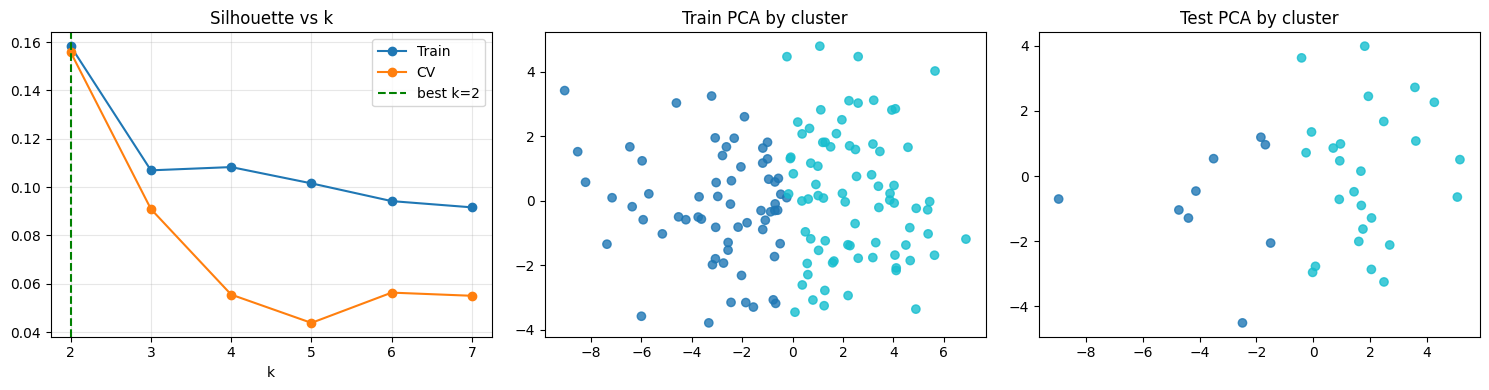

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(k_range), train_sils, "o-", label="Train")
axes[0].plot(list(k_range), cv_sils, "o-", label="CV")
axes[0].axvline(best_k, color="green", ls="--", label=f"best k={best_k}")
axes[0].set_title("Silhouette vs k")
axes[0].set_xlabel("k")
axes[0].legend()
axes[0].grid(alpha=0.3)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters, cmap="tab10", alpha=0.8)
axes[1].set_title("Train PCA by cluster")

axes[2].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=test_clusters, cmap="tab10", alpha=0.8)
axes[2].set_title("Test PCA by cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "overview.png", dpi=150)
plt.show()


## 7.1. 3D PCA

PCA на 3 компоненты (fit только на train). Слева — по кластерам, справа — по диагнозу.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
train_3d = pca3.fit_transform(X_train_scaled)
test_3d = pca3.transform(X_test_scaled)
var = pca3.explained_variance_ratio_

fig = plt.figure(figsize=(14, 10))

# --- Train: clusters ---
ax = fig.add_subplot(2, 2, 1, projection="3d")
sc = ax.scatter(
    train_3d[:, 0], train_3d[:, 1], train_3d[:, 2],
    c=train_clusters, cmap="tab10", s=35, alpha=0.85, depthshade=True,
)
ax.set_title("Train: clusters")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var[2]*100:.1f}%)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="cluster")

# --- Train: diagnosis ---
ax = fig.add_subplot(2, 2, 2, projection="3d")
sc = ax.scatter(
    train_3d[:, 0], train_3d[:, 1], train_3d[:, 2],
    c=y_train.values, cmap="coolwarm", s=35, alpha=0.85, depthshade=True,
)
ax.set_title("Train: diagnosis (H=0, P=1)")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var[2]*100:.1f}%)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="class")

# --- Test: clusters ---
ax = fig.add_subplot(2, 2, 3, projection="3d")
sc = ax.scatter(
    test_3d[:, 0], test_3d[:, 1], test_3d[:, 2],
    c=test_clusters, cmap="tab10", s=50, alpha=0.9, depthshade=True,
)
ax.set_title("Test: clusters")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var[2]*100:.1f}%)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="cluster")

# --- Test: diagnosis ---
ax = fig.add_subplot(2, 2, 4, projection="3d")
sc = ax.scatter(
    test_3d[:, 0], test_3d[:, 1], test_3d[:, 2],
    c=y_test.values, cmap="coolwarm", s=50, alpha=0.9, depthshade=True,
)
ax.set_title("Test: diagnosis (H=0, P=1)")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({var[2]*100:.1f}%)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="class")

plt.suptitle(
    f"3D PCA (explained: {var.sum()*100:.1f}% by PC1–PC3)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "pca_3d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Explained variance PC1–PC3: {var[0]:.3f}, {var[1]:.3f}, {var[2]:.3f} (sum={var.sum():.3f})")
print(f"Saved: {OUTPUT_DIR / 'figures' / 'pca_3d.png'}")


In [9]:
summary = pd.DataFrame(
    {
        "metric": [
            "silhouette_train",
            "silhouette_test",
            "silhouette_cv_mean",
            "silhouette_cv_std",
            "ari_train",
            "ari_test",
            "ari_cv_mean",
            "ari_cv_std",
            "ami_train",
            "ami_test",
            "acc_mapped_train",
            "acc_mapped_test",
            "f1_mapped_train",
            "f1_mapped_test",
            "auc_mapped_train",
            "auc_mapped_test",
            "best_k",
            "n_features",
        ],
        "value": [
            sil_train,
            sil_test,
            float(np.mean(cv_sil_folds)),
            float(np.std(cv_sil_folds)),
            ari_train,
            ari_test,
            float(np.mean(cv_ari_folds)),
            float(np.std(cv_ari_folds)),
            ami_train,
            ami_test,
            acc_train,
            acc_test,
            f1_train,
            f1_test,
            auc_train,
            auc_test,
            best_k,
            len(remaining_features),
        ],
    }
)
summary.to_csv(OUTPUT_DIR / "logs" / "honest_metrics.csv", index=False)
print(summary.to_string(index=False))
print(f"\nSaved under: {OUTPUT_DIR.resolve()}")


            metric     value
  silhouette_train  0.158317
   silhouette_test  0.219501
silhouette_cv_mean  0.155835
 silhouette_cv_std  0.022228
         ari_train  0.213036
          ari_test  0.044483
       ari_cv_mean  0.235057
        ari_cv_std  0.207152
         ami_train  0.164956
          ami_test  0.057075
  acc_mapped_train  0.733813
   acc_mapped_test  0.628571
   f1_mapped_train  0.721805
    f1_mapped_test  0.518519
  auc_mapped_train  0.735087
   auc_mapped_test  0.635621
            best_k  2.000000
        n_features 38.000000

Saved under: C:\Users\Dezhurny\Desktop\final\Final_project_AD\hw6_AD_final_project\outputs_fixed
